# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is the process of understanding a dataset
using summary statistics and visualizations before applying statistical
or machine learning models.

In [1]:
print("Jupyter is working!")

Jupyter is working!


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Dataset

In [23]:
df = pd.read_csv("../data/WineQT.csv")

In [24]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Understanding the Dataset

In [25]:
df.shape

(1143, 13)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [27]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## Data Quality Check

In [28]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

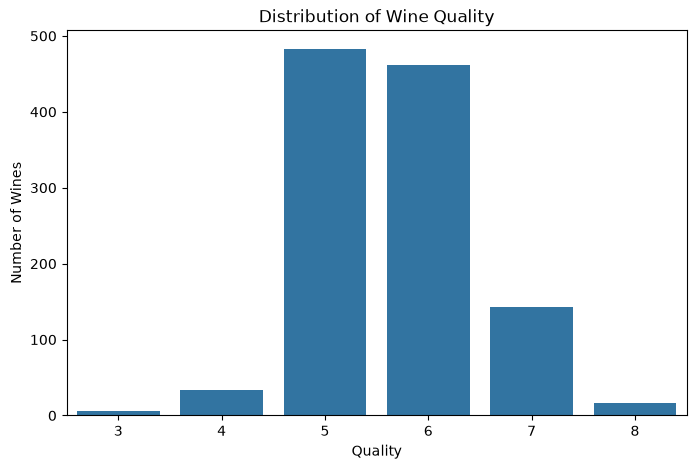

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")
plt.show()

## Distribution of Wine Quality

The distribution of wine quality helps us understand how frequently each
quality score occurs in the dataset.

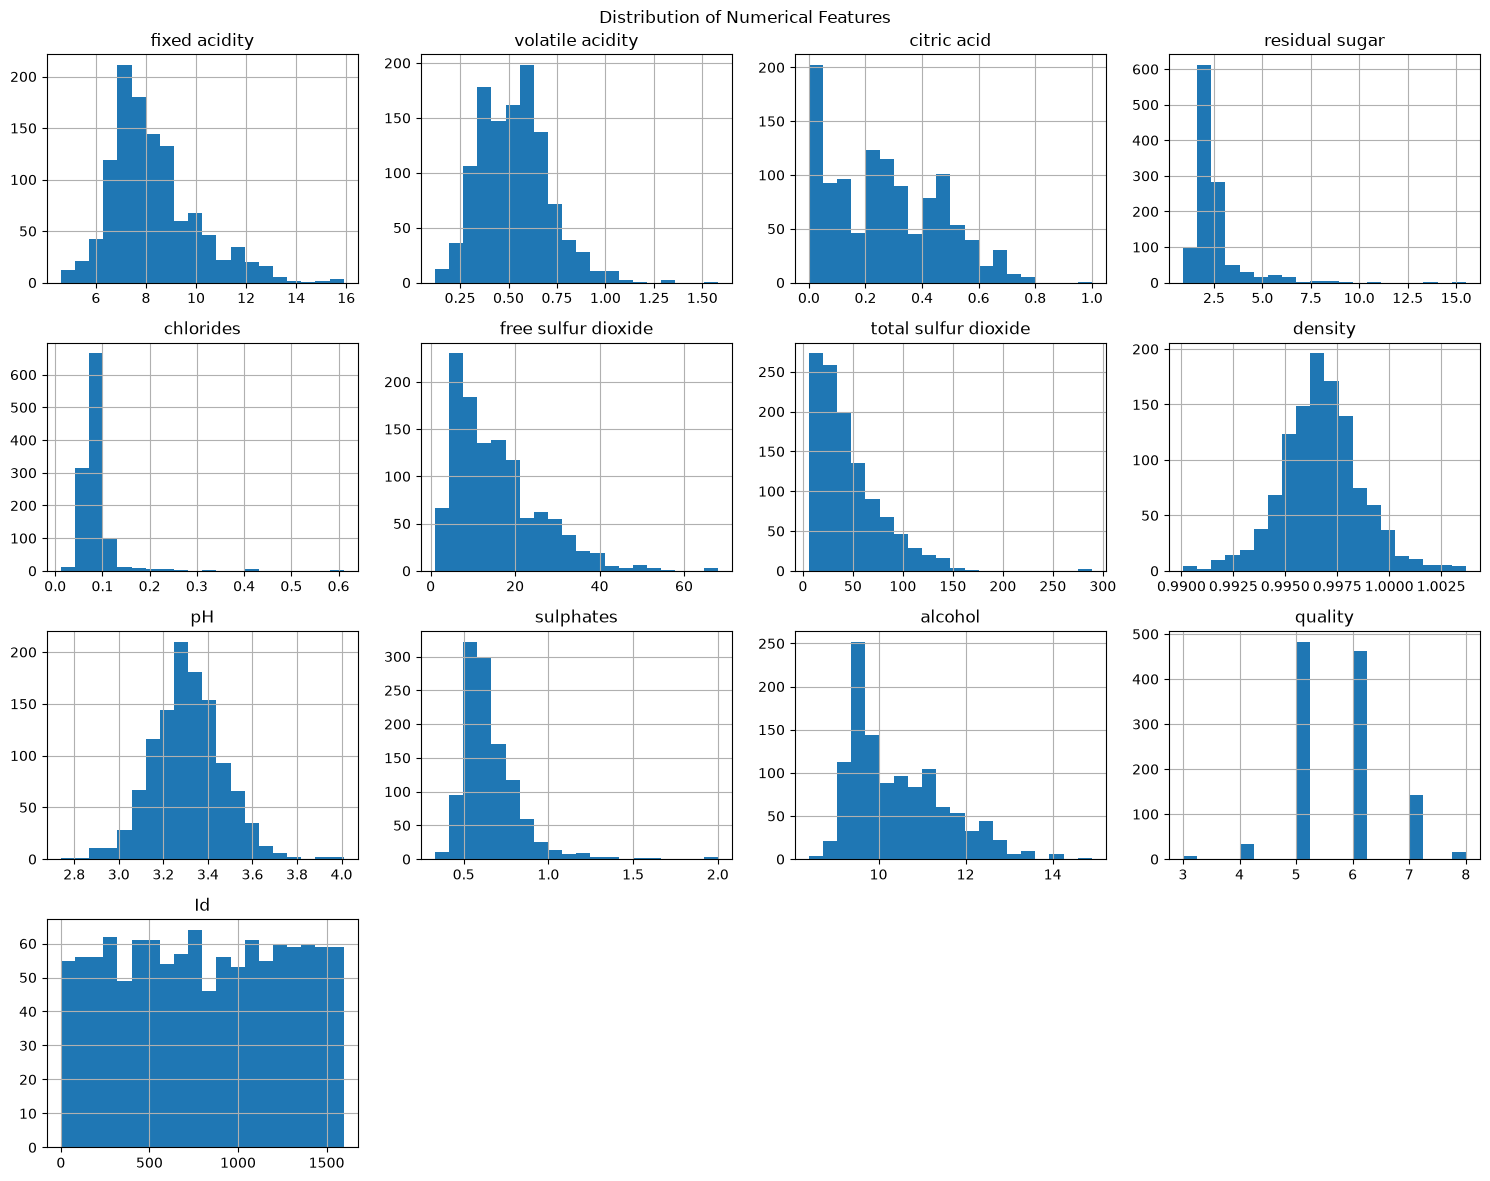

In [32]:
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

### Observation

The histograms show that the numerical features have different
distribution patterns.

Several variables such as residual sugar, chlorides, free sulfur dioxide,
total sulfur dioxide, sulphates, and alcohol show right-skewed
distributions, indicating that most observations are concentrated at
lower values with a smaller number of higher values.

Density and pH appear relatively symmetric compared with the other
features. The quality variable is discrete and is concentrated mainly
around quality scores 5 and 6.

The `Id` column represents an identifier and does not provide meaningful
continuous measurements for distribution analysis.

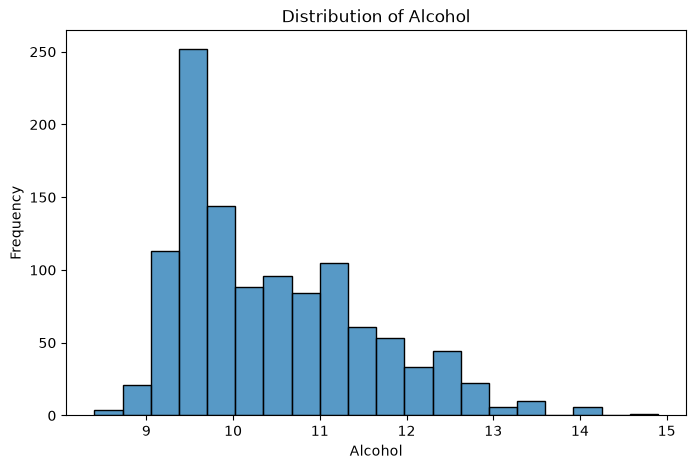

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="alcohol", bins=20)

plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

### Observation: Alcohol Distribution

The alcohol variable is concentrated mainly between approximately 9% and
11%. The distribution has a noticeable right tail, with fewer observations
at higher alcohol levels.

This indicates that the alcohol variable is positively (right) skewed
rather than perfectly normally distributed.

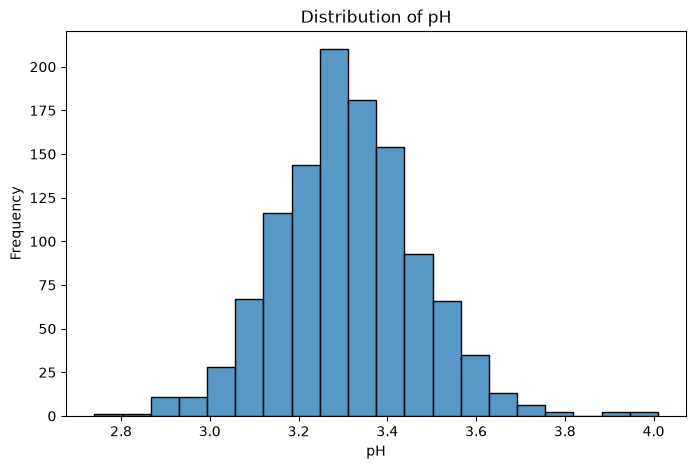

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="pH", bins=20)

plt.title("Distribution of pH")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

### Observation: pH Distribution

The pH values are mainly concentrated between approximately 3.1 and 3.5,
with the highest frequency around 3.3.

The distribution appears relatively symmetric and approximately
bell-shaped, although it is not perfectly normal. Only a small number of
observations occur at the extreme lower and higher pH values.

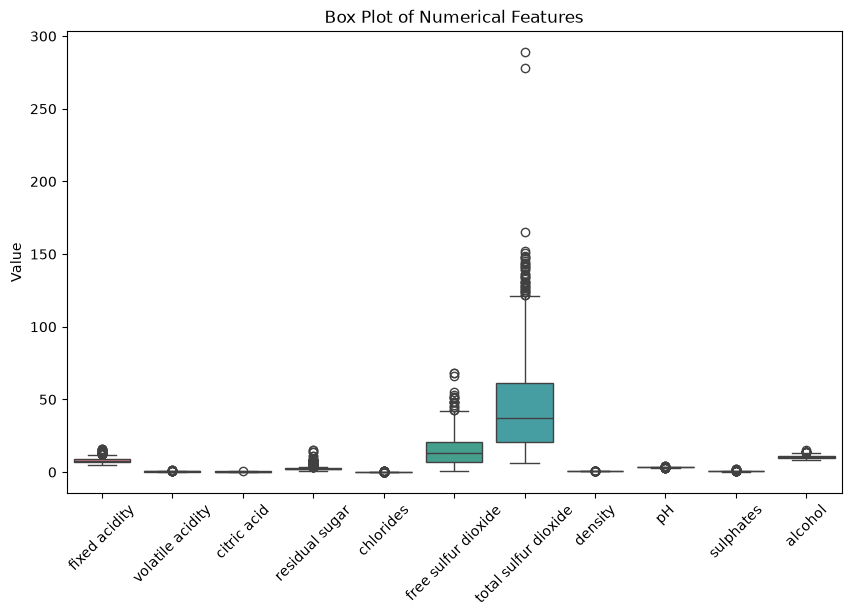

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[[
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]])

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Value")
plt.show()

### Observation: Box Plot

The box plot shows that several numerical features contain potential
outliers and have different levels of variability.

Features such as free sulfur dioxide and total sulfur dioxide show a
larger spread and several extreme observations. Other variables also
contain observations outside their main interquartile range.

The features have considerably different scales, so the box plot is mainly
useful here for identifying spread and potential outliers rather than
comparing absolute magnitudes.

A detailed IQR-based outlier analysis will be performed separately in the
IQR notebook.

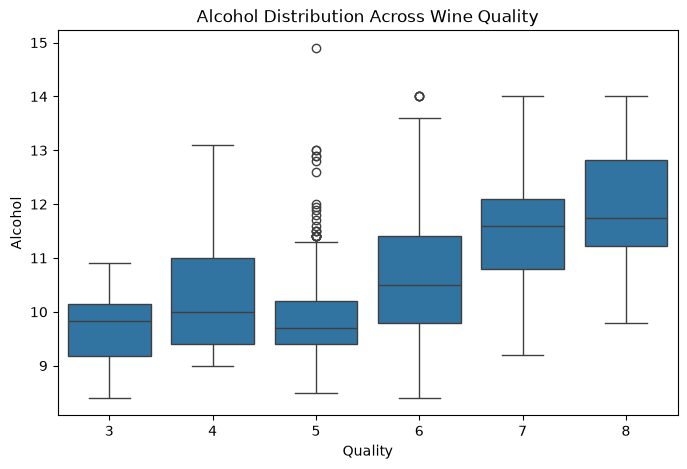

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="quality", y="alcohol")

plt.title("Alcohol Distribution Across Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

### Observation: Alcohol vs Wine Quality

The box plot suggests a positive relationship between alcohol content and
wine quality. The median alcohol level generally increases as the quality
score increases.

Wines with quality scores of 7 and 8 tend to have higher alcohol levels
than wines with lower quality scores. However, there is considerable
variation within each quality group, so alcohol alone does not determine
wine quality.

Several potential outliers are also visible, particularly for quality 5.

In [37]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


### Observation: Correlation Matrix

The correlation matrix shows the strength and direction of the linear
relationship between numerical variables.

Alcohol has the strongest positive correlation with quality
(approximately 0.48), indicating that higher alcohol content tends to be
associated with higher wine quality.

Volatile acidity has a moderate negative correlation with quality
(approximately -0.41), suggesting that higher volatile acidity tends to
be associated with lower quality.

Correlation values range from -1 to +1, where values closer to +1 indicate
a strong positive relationship, values closer to -1 indicate a strong
negative relationship, and values near 0 indicate a weak linear
relationship.

Correlation does not imply causation.

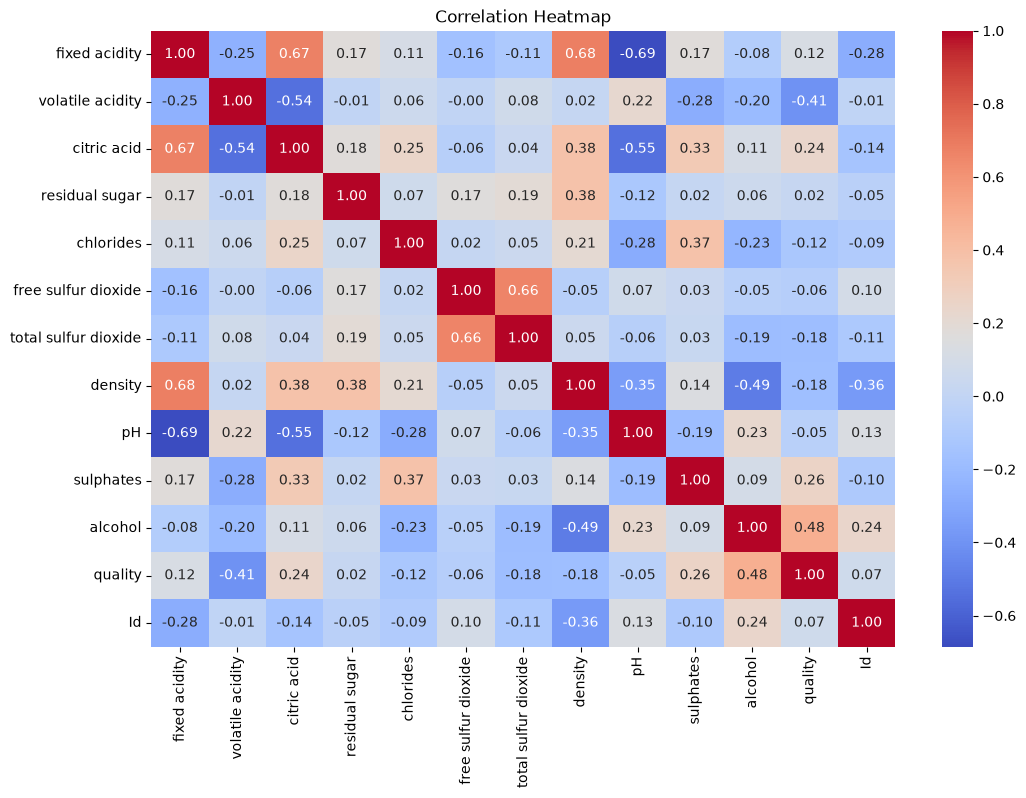

In [38]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation: Correlation Heatmap

The correlation heatmap provides a visual representation of the
relationships between numerical features.

Alcohol shows the strongest positive correlation with quality, while
volatile acidity shows a notable negative correlation.

A relatively strong positive relationship can also be observed between
free sulfur dioxide and total sulfur dioxide. Fixed acidity and citric
acid also show a positive relationship.

The heatmap helps identify potentially important relationships and
features that may require further investigation during analysis or
model building.

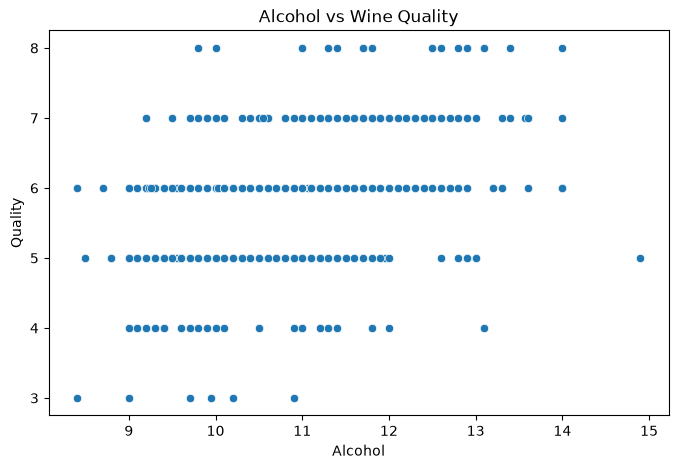

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="alcohol", y="quality")

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

### Observation: Alcohol vs Wine Quality

The scatter plot shows a positive relationship between alcohol content
and wine quality. Higher quality scores are generally associated with
higher alcohol levels.

However, the observations show considerable variation within each quality
level. Therefore, alcohol content alone cannot fully explain wine quality.

##  Key Insights from EDA

The exploratory analysis of the Wine Quality dataset produced the
following key insights:

- The dataset contains 1,143 observations and 13 variables.
- No missing values were found.
- No duplicate rows were found.
- Wine quality is concentrated mainly around scores 5 and 6.
- Several numerical features are right-skewed.
- The pH distribution is relatively symmetric and approximately
  bell-shaped.
- Several numerical variables show potential outliers.
- Alcohol has a moderate positive relationship with wine quality.
- Volatile acidity has a moderate negative relationship with wine quality.
- Different physicochemical properties have different distributions and
  relationships with each other.

##  Conclusion

EDA helped us understand the structure, quality, distributions, outliers,
and relationships present in the Wine Quality dataset.

The analysis shows that the dataset is structurally clean, with no
missing or duplicate observations. However, several variables have
skewed distributions and potential outliers that should be considered
during further analysis.

Alcohol and volatile acidity show notable relationships with wine
quality, while the quality variable itself is concentrated mainly around
scores 5 and 6.

These findings provide a foundation for further statistical analysis and
data processing. Detailed analysis of normal distribution, IQR-based
outlier detection, KDE, and contour plots will be performed in their
respective notebooks.